# NeMo Safe Synthesizer Tutorial: Time-Series Financial Transactions

#### What you'll learn

In this notebook, we'll explore how to use NeMo Safe Synthesizer for a financial transaction time series: loading an account-level transaction dataset, configuring the synthesizer for grouped temporal data, generating synthetic transaction histories, and checking whether the synthetic data preserves privacy and transaction patterns.

We will answer two questions:

1. Does the synthetic data avoid direct memorization of transaction rows?
2. Does it preserve the data structure and behavioral patterns that matter for financial analytics?

A full run takes about 20 minutes on an A100. If you have not yet completed the [Safe Synthesizer 101](safe-synthesizer-101.ipynb) tutorial, consider starting there first.

### Prerequisites

This notebook requires:

- A Linux machine with an NVIDIA GPU (H100 recommended, A100 minimum) and CUDA 12.9+. It will not run on macOS, Windows, or Apple Silicon.
- The `docs/tutorials/datasets/financial_transactions_DD_0526.csv` dataset.
- An optional `NSS_INFERENCE_KEY` for PII column classification.

### Install Safe Synthesizer

Run the cell below to install NeMo Safe Synthesizer with the engine and CUDA 12.9 extras.

If NeMo Safe Synthesizer is already installed in your notebook environment, you can skip this cell.

In [1]:
%%bash
# SPDX-FileCopyrightText: Copyright (c) 2025-2026 NVIDIA CORPORATION & AFFILIATES. All rights reserved.
# SPDX-License-Identifier: Apache-2.0

if command -v uv > /dev/null 2>&1; then
    uv pip install "nemo-safe-synthesizer[engine,cu129]" --index https://flashinfer.ai/whl/cu129 --index https://download.pytorch.org/whl/cu129 --index https://wheels.vllm.ai/88d34c6409e9fb3c7b8ca0c04756f061d2099eb1/cu129 --index-strategy unsafe-best-match
else
    pip install "nemo-safe-synthesizer[engine,cu129]" --extra-index-url https://flashinfer.ai/whl/cu129 --extra-index-url https://download.pytorch.org/whl/cu129 --extra-index-url https://wheels.vllm.ai/88d34c6409e9fb3c7b8ca0c04756f061d2099eb1/cu129
fi

Using Python 3.11.14 environment at: /root/Safe-Synthesizer/.venv
Audited 1 package in 16ms


### Set the Inference API Key for PII Column Classification

This notebook enables PII replacement through the SDK builder. NeMo Safe Synthesizer can use an LLM-based column classifier to infer PII columns; set `NSS_INFERENCE_KEY` to enable that classifier. You can press Enter to skip, but the privacy story is stronger when PII classification is available.

In [2]:
import getpass
import os

if "NSS_INFERENCE_KEY" not in os.environ:
    os.environ["NSS_INFERENCE_KEY"] = getpass.getpass("Paste inference API key (or press Enter to skip): ")

if os.environ.get("NSS_INFERENCE_KEY"):
    print("NSS_INFERENCE_KEY is set")
else:
    print(
        "NSS_INFERENCE_KEY is not set. PII replacement may run in degraded mode. "
        "For a privacy-focused demo, set a key and rerun this cell."
    )

NSS_INFERENCE_KEY is set


In [3]:
from __future__ import annotations

import base64
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import IFrame, Markdown, display

plt.rcParams.update({
    "figure.figsize": (11, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

### Load the Financial Transactions Dataset

Load `financial_transactions_DD_0526.csv` and confirm the expected row and column counts. The dataset is already in the long format that NeMo Safe Synthesizer expects for time-series synthesis: rows sharing the same `acct_id` form one transaction sequence, and `txn_index` provides the ordering within each account.

In [4]:
ORIGINAL_CSV = "datasets/financial_transactions_DD_0526.csv"
ARTIFACT_ROOT = "safe-synthesizer-artifacts"

source_df = pd.read_csv(ORIGINAL_CSV)

pd.DataFrame(
    [{
        "input": "Original CSV",
        "path": ORIGINAL_CSV,
        "rows": len(source_df),
        "columns": len(source_df.columns),
    }]
)

,input,path,rows,columns
0,Original CSV,datasets/financial_transactions_DD_0526.csv,4700,8


### Preview the Original Dataset

The source data is a transaction ledger: repeated account-level fields, a chronological transaction index, merchant category/name, timestamp, and amount. Direct identifiers such as `acct_id` and `cardholder` are useful for demonstrating privacy checks, but should be treated carefully in production synthetic-data workflows.

In [5]:
display(source_df.head(5))

display(pd.DataFrame({
    "column": source_df.columns,
    "dtype": source_df.dtypes.astype(str).values,
    "non_null": source_df.notna().sum().values,
    "unique_values": source_df.nunique(dropna=True).values,
}))

,acct_id,cardholder,state,txn_index,timestamp,merchant_cat,merchant,txn_amount
0,ACCT-013E4482,Alexis Parsons,CA,1,2025-01-02 21:20:56,entertainment,AMC Theatres,158.40
1,ACCT-013E4482,Alexis Parsons,CA,2,2025-01-03 09:55:05,subscription,Spotify,12.99
2,ACCT-013E4482,Alexis Parsons,CA,3,2025-01-03 10:49:25,healthcare,Walgreens,1529.73
3,ACCT-013E4482,Alexis Parsons,CA,4,2025-01-03 17:05:01,retail,Best Buy,94.89
4,ACCT-013E4482,Alexis Parsons,CA,5,2025-01-04 00:00:07,subscription,Netflix,12.99


,column,dtype,non_null,unique_values
0,acct_id,object,4700,50
1,cardholder,object,4700,50
2,state,object,4700,22
3,txn_index,int64,4700,94
4,timestamp,object,3980,3969
5,merchant_cat,object,3980,14
6,merchant,object,3979,157
7,txn_amount,float64,3980,3203


### Configure and Run Safe Synthesizer

Create the Safe Synthesizer builder and configure it for financial transaction time-series synthesis:

- `with_time_series` enables time-series mode and uses `txn_index` as the sequence timestamp.
- `with_data` tells the synthesizer that rows sharing the same `acct_id` belong to one account history, ordered by `txn_index`.
- `with_replace_pii` enables PII replacement, while preserving two-letter state abbreviations as categorical values.
- `with_train` sets demo-specific training hyperparameters for the `HuggingFaceTB/SmolLM3-3B` base model.
- `with_generate` requests 4,500 synthetic rows.

Refer to the [configuration docs](../user-guide/configuration.md) for the full list of options.

In [6]:
from nemo_safe_synthesizer.config.replace_pii import PiiReplacerConfig
from nemo_safe_synthesizer.sdk.library_builder import SafeSynthesizer

pii_config = PiiReplacerConfig.get_default_config()
pii_config.globals.classify.entities = [
    entity for entity in pii_config.globals.classify.entities if entity != "state"
]
if pii_config.globals.ner.ner_entities is not None:
    pii_config.globals.ner.ner_entities = [
        entity for entity in pii_config.globals.ner.ner_entities if entity != "state"
    ]

builder = (
    SafeSynthesizer(save_path=ARTIFACT_ROOT)
    .with_data_source(source_df)
    .with_time_series(
        is_timeseries=True,
        timestamp_column="txn_index",
    )
    .with_data(
        holdout=0,
        group_training_examples_by="acct_id",
        order_training_examples_by="txn_index",
    )
    .with_replace_pii(config=pii_config)
    .with_train(
        pretrained_model="HuggingFaceTB/SmolLM3-3B",
        num_input_records_to_sample=60000,
        learning_rate=5.0e-4,
        lora_r=32,
    )
)

builder.run()
results = builder.results

RUN_PATH = Path(builder._workdir.generate.path).parent

pd.DataFrame(
    [{
        "artifact": "Safe Synthesizer run path",
        "path": str(RUN_PATH),
        "synthetic_rows": len(results.synthetic_data),
    }]
)

2026-06-04T14:02:45.257 | Nemo Safe Synthesizer |  runtime |  info  |  parameters.py: 136 
Setting max_sequences_per_example to None for time-series mode so each example fills the context window.
2026-06-04T14:02:45.277 | Nemo Safe Synthesizer |  user    |  info  |  orchestrator.py: 196 
Preflight: 9 check(s) ran, 0 skipped — 0 error(s), 0 warning(s)
2026-06-04T14:02:45.357 | Nemo Safe Synthesizer |  runtime |  info  |  autoconfig.py: 121 
Estimated max token count for examples in dataset - this is used to determine the rope scaling factor: 7851.5
2026-06-04T14:02:45.358 | Nemo Safe Synthesizer |  runtime |  info  |  autoconfig.py: 186 
Parameter `rope_scaling_factor` was automatically set to 1 based on an estimated token count given the lengths of each training record and the column names.
2026-06-04T14:02:45.358 | Nemo Safe Synthesizer |  runtime |  info  |  autoconfig.py: 214 
`learning_rate` was set to 0.0005, using that value
2026-06-04T14:02:45.359 | Nemo Safe Synthesizer |  runt

/root/Safe-Synthesizer/.venv/lib/python3.11/site-packages/huggingface_hub/utils/_validators.py:189: UserWarning: The `resume_download` argument is deprecated and ignored in `snapshot_download`. Downloads always resume whenever possible.
  warnings.warn(


Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

2026-06-04T14:02:45.439 | Nemo Safe Synthesizer |  runtime |  info  |  model.py: 2798 
Loading the following GLiNER type: <class 'gliner.model.UniEncoderSpanGLiNER'>...
2026-06-04T14:02:50.735 | Nemo Safe Synthesizer |  runtime |  info  |  nemo_pii.py: 121 
PII column classification will call the default NVIDIA inference API at https://integrate.api.nvidia.com/v1. To use another server, set the NSS_INFERENCE_ENDPOINT environment variable to a NIM/OpenAI-compatible endpoint.
2026-06-04T14:02:53.526 | Nemo Safe Synthesizer |  runtime |  info  |  detect.py: 275 
LLM column classification took 2.7687041480094194 seconds. 
2026-06-04T14:02:53.542 | Nemo Safe Synthesizer |  user    |  info  |  edit.py: 717 
Executing transform step : 0 / 1


               Transformation Progress                
+----------------------------------------------------+
| Metric         | Value                             |
|----------------+-----------------------------------|
| Transform Time | 2.6 seconds                       |
| Step           | 1 of 1                            |
| Rule           | 3 of 11                           |
| Column         | "cardholder", #2 of 8             |
| Progress       | 4700 rows out of 4700 transformed |
| Speed          | 🐇 1816.5 rows per second.        |
+----------------------------------------------------+

...

2026-06-04T14:24:21.889 | Nemo Safe Synthesizer |  runtime |  info  |  timeseries_backend.py: 816 
Group 'ACCT-CCBFD577' completed (stop timestamp reached). Progress: 41/50 groups.
2026-06-04T14:24:21.891 | Nemo Safe Synthesizer |  runtime |  info  |  timeseries_backend.py: 816 
Group 'ACCT-D430CF25' completed (stop timestamp reached). Progress: 42/50 groups.
2026-06-04T14:24:21.893 | Nemo Safe Synthesizer |  runtime |  info  |  timeseries_backend.py: 816 
Group 'ACCT-D531DC19' completed (stop timestamp reached). Progress: 43/50 groups.
2026-06-04T14:24:21.894 | Nemo Safe Synthesizer |  runtime |  info  |  timeseries_backend.py: 816 
Group 'ACCT-E15C9DBE' completed (stop timestamp reached). Progress: 44/50 groups.
2026-06-04T14:24:21.896 | Nemo Safe Synthesizer |  runtime |  info  |  timeseries_backend.py: 816 
Group 'ACCT-E32721A2' completed (stop timestamp reached). Progress: 45/50 groups.
2026-06-04T14:24:21.897 | Nemo Safe Synthesizer |  runtime |  info  |  timeseries_backend.py: 8

[rank0]:[W604 14:24:23.080117142 ProcessGroupNCCL.cpp:1575] Warning: WARNING: destroy_process_group() was not called before program exit, which can leak resources. For more info, please see https://pytorch.org/docs/stable/distributed.html#shutdown (function operator())


2026-06-04T14:24:25.084 | Nemo Safe Synthesizer |  runtime |  info  |  evaluator.py: 79 
Performing Evaluation.
2026-06-04T14:24:25.087 | Nemo Safe Synthesizer |  runtime |  info  |  evaluation_datasets.py: 213 
Subsampling training data from 4700 records to 4550.
2026-06-04T14:24:45.199 | Nemo Safe Synthesizer |  runtime |  info  |  membership_inference_protection.py: 455 
No test data provided for Membership Inference Attack. Skipping Membership Inference Attack.
2026-06-04T14:24:47.331 | Nemo Safe Synthesizer |  runtime |  info  |  evaluator.py: 90 
Evaluation complete.
2026-06-04T14:24:48.716 | Nemo Safe Synthesizer |  runtime |  info  |  library_builder.py: SafeSynthesizer.run: 619 
Entering SafeSynthesizer.save_results
2026-06-04T14:24:48.729 | Nemo Safe Synthesizer |  runtime |  info  |  library_builder.py: 657 
Saved synthetic data to safe-synthesizer-artifacts/default---data/2026-06-04T14:02:45/generate/synthetic_data.csv
2026-06-04T14:24:48.730 | Nemo Safe Synthesizer |  runt

/root/Safe-Synthesizer/src/nemo_safe_synthesizer/telemetry.py:463: RuntimeWarning:

coroutine 'TelemetryHandler._flush_events' was never awaited



,artifact,path,synthetic_rows
0,Safe Synthesizer run path,safe-synthesizer-artifacts/default---data/2026...,4550


### Review the Built-In Evaluation Report

Safe Synthesizer generates a built-in evaluation report as part of `builder.run()`. Review this first for the standard quality and privacy assessment before moving into the transaction-specific analysis below.

In [7]:
report_html = results.evaluation_report_html
if report_html:
    data_url = "data:text/html;base64," + base64.b64encode(report_html.encode("utf-8")).decode("ascii")
    display(IFrame(src=data_url, width="100%", height=800))
else:
    display(Markdown("Safe Synthesizer did not return an HTML evaluation report for this run."))

### Retrieve Synthetic Data

After the run completes, Safe Synthesizer exposes the generated dataset on `builder.results`. The rest of the notebook uses this in-memory result directly.

In [8]:
synthetic_output = results.synthetic_data.copy()

print(f"Number of synthetic rows: {len(synthetic_output):,}")
display(synthetic_output.head())
print(f"Artifacts saved to: {RUN_PATH}")

Number of synthetic rows: 4,550


,acct_id,cardholder,state,txn_index,timestamp,merchant_cat,merchant,txn_amount
0,ACCT-013E4482,Daniel Jones,CA,4,2025-01-03 18:41:40,dining,McDonald's,60.12
1,ACCT-013E4482,Daniel Jones,CA,5,2025-01-04 00:00:37,subscription,Netflix,15.99
2,ACCT-013E4482,Daniel Jones,CA,6,2025-01-04 17:51:10,retail,Best Buy,101.69
3,ACCT-013E4482,Daniel Jones,CA,7,2025-01-05 12:45:46,travel,Delta Air Lines,239.97
4,ACCT-013E4482,Daniel Jones,CA,8,2025-01-05 15:15:49,automotive,Midas,17.78


Artifacts saved to: safe-synthesizer-artifacts/default---data/2026-06-04T14:02:45


### Prepare Data for Analysis

Safe Synthesizer generated a time-series dataset. The result can include padded continuation rows where the account-level context is present but transaction detail fields are empty. We keep the raw DataFrames for schema and missingness checks, then create transaction-valid views for behavioral analysis.

In [9]:
def prepare_transactions(df: pd.DataFrame, source: str) -> pd.DataFrame:
    prepared = df.copy()
    prepared["source"] = source
    prepared["txn_amount"] = pd.to_numeric(prepared["txn_amount"], errors="coerce")
    prepared["txn_index"] = pd.to_numeric(prepared["txn_index"], errors="coerce")
    prepared["timestamp_dt"] = pd.to_datetime(prepared["timestamp"], errors="coerce")
    prepared["hour"] = prepared["timestamp_dt"].dt.hour
    prepared["day"] = prepared["timestamp_dt"].dt.day
    return prepared


original_raw = prepare_transactions(source_df, "Original")
synthetic_raw = prepare_transactions(synthetic_output, "Synthetic")

transaction_detail_cols = ["timestamp", "merchant_cat", "merchant", "txn_amount"]
original = original_raw.dropna(subset=["timestamp_dt", "merchant_cat", "txn_amount"]).copy()
synthetic = synthetic_raw.dropna(subset=["timestamp_dt", "merchant_cat", "txn_amount"]).copy()
combined = pd.concat([original, synthetic], ignore_index=True)
raw_combined = pd.concat([original_raw, synthetic_raw], ignore_index=True)

summary = pd.DataFrame([
    {
        "source": name,
        "valid_transaction_rows": len(clean),
        "unique_accounts": raw["acct_id"].nunique(),
        "valid_rows_per_account_median": clean.groupby("acct_id").size().median(),
    }
    for name, raw, clean in [
        ("Original", original_raw, original),
        ("Synthetic", synthetic_raw, synthetic),
    ]
])
summary

,source,valid_transaction_rows,unique_accounts,valid_rows_per_account_median
0,Original,3980,50,79.0
1,Synthetic,3905,50,78.0


In [10]:
CATEGORY_ORDER = [
    "grocery", "dining", "retail", "e-commerce", "subscription", "entertainment",
    "gas", "healthcare", "utilities", "automotive", "ATM", "travel",
    "wire_transfer", "other",
]


def pct_by_category(df: pd.DataFrame) -> pd.Series:
    return df["merchant_cat"].value_counts(normalize=True).reindex(CATEGORY_ORDER, fill_value=0)


def row_hashes(df: pd.DataFrame, columns: list[str]) -> set[str]:
    normalized = df[columns].fillna("<NA>").astype(str)
    return {
        hashlib.sha256("||".join(row).encode("utf-8")).hexdigest()
        for row in normalized.to_numpy()
    }


def plot_grouped_bars(frame: pd.DataFrame, title: str, ylabel: str, *, ax=None):
    ax = frame.plot(kind="bar", ax=ax, width=0.82)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(frameon=False)
    return ax


def valid_rate(raw: pd.DataFrame) -> float:
    return raw[transaction_detail_cols].notna().all(axis=1).mean()



### Visual Comparison: Category Mix

A useful synthetic transaction dataset should preserve the category base rates: grocery and dining should be common, wire transfers should remain rare, and the middle-frequency categories should stay in the same neighborhood.

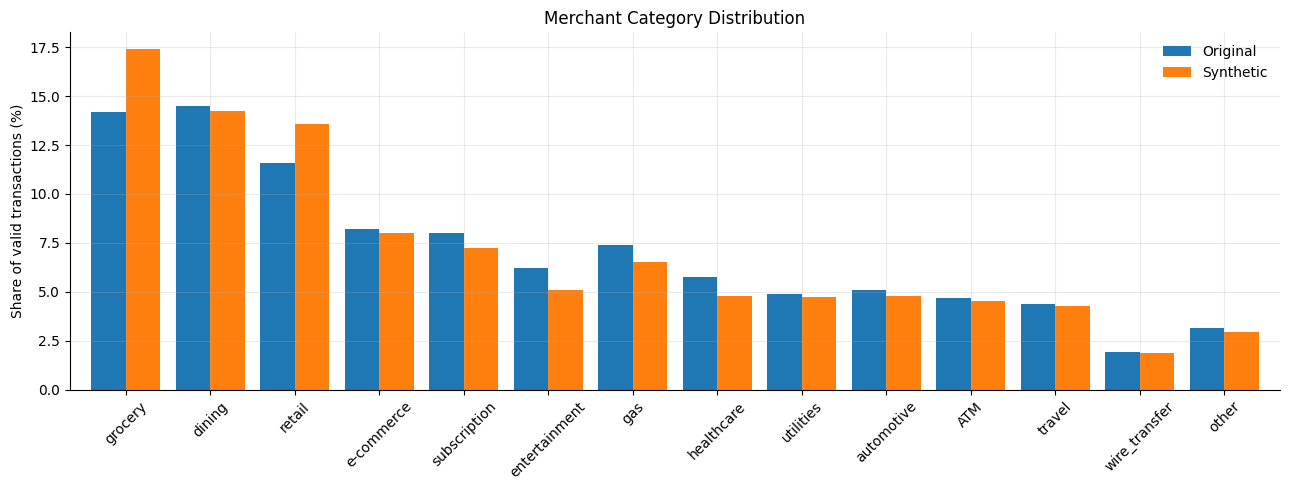

In [11]:
category_mix = pd.DataFrame({
    "Original": pct_by_category(original) * 100,
    "Synthetic": pct_by_category(synthetic) * 100,
})
category_delta = category_mix.assign(
    synthetic_minus_original_pp=category_mix["Synthetic"] - category_mix["Original"],
)

fig, ax = plt.subplots(figsize=(13, 5))
plot_grouped_bars(category_mix, "Merchant Category Distribution", "Share of valid transactions (%)", ax=ax)
plt.tight_layout()
plt.show()

### Visual Comparison: Amount Distributions

Financial utility often depends on tails and conditional distributions, not just averages. The plots below use a log-scaled amount axis so daily spend, healthcare/procedure amounts, travel, and wire transfers can be inspected together.

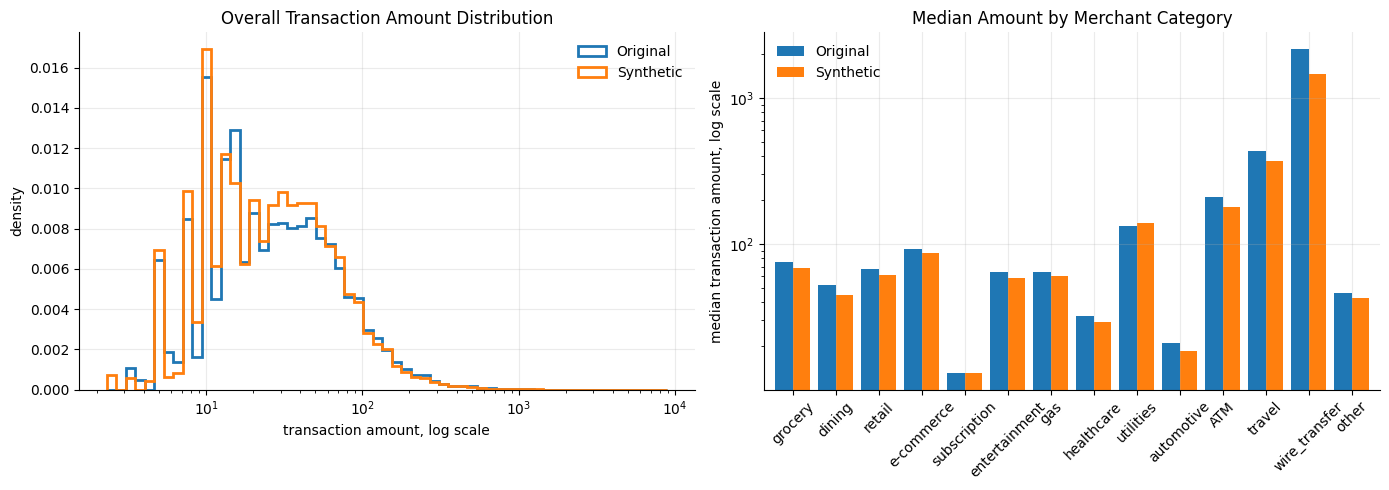

,count,mean,std,min,50%,90%,95%,99%,max
source,,,,,,,,,
Original,3980.0,159.79,430.75,3.41,68.21,278.16,494.57,2066.39,6652.51
Synthetic,3905.0,140.20,419.47,2.32,62.51,241.40,401.61,1443.79,8848.84


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bins = np.logspace(np.log10(max(1, combined["txn_amount"].min())), np.log10(combined["txn_amount"].max()), 60)
for source, frame in combined.groupby("source"):
    axes[0].hist(frame["txn_amount"], bins=bins, density=True, histtype="step", linewidth=2, label=source)
axes[0].set_xscale("log")
axes[0].set_title("Overall Transaction Amount Distribution")
axes[0].set_xlabel("transaction amount, log scale")
axes[0].set_ylabel("density")
axes[0].legend(frameon=False)

amount_summary = (
    combined.groupby(["source", "merchant_cat"])["txn_amount"]
    .median()
    .unstack(0)
    .reindex(CATEGORY_ORDER)
)
amount_summary.plot(kind="bar", ax=axes[1], width=0.82)
axes[1].set_title("Median Amount by Merchant Category")
axes[1].set_yscale("log")
axes[1].set_ylabel("median transaction amount, log scale")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

display(
    combined.groupby("source")["txn_amount"]
    .describe(percentiles=[0.5, 0.9, 0.95, 0.99])
    .round(2)
)

### Visual Comparison: Time-of-Day Patterns

The source data contains strong temporal priors: dining peaks later than healthcare, entertainment is mostly evening, and subscriptions can occur overnight. The heatmaps below compare whether those category-specific temporal signatures survived synthesis.

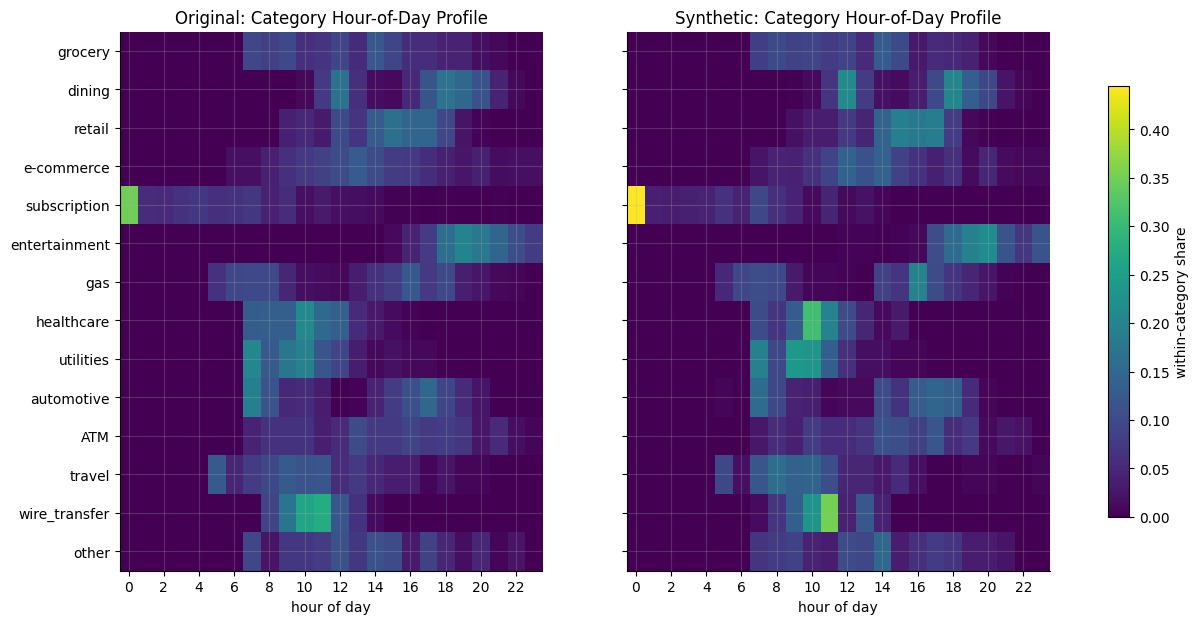

In [13]:
def hour_category_matrix(df: pd.DataFrame) -> pd.DataFrame:
    mat = (
        df.pivot_table(index="merchant_cat", columns="hour", values="txn_amount", aggfunc="size", fill_value=0)
        .reindex(index=CATEGORY_ORDER, columns=range(24), fill_value=0)
    )
    return mat.div(mat.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)

orig_hour = hour_category_matrix(original)
synth_hour = hour_category_matrix(synthetic)

fig, axes = plt.subplots(1, 2, figsize=(15, 7), sharey=True)
for ax, mat, title in [(axes[0], orig_hour, "Original"), (axes[1], synth_hour, "Synthetic")]:
    im = ax.imshow(mat.values, aspect="auto", cmap="viridis", vmin=0, vmax=max(orig_hour.max().max(), synth_hour.max().max()))
    ax.set_title(f"{title}: Category Hour-of-Day Profile")
    ax.set_xlabel("hour of day")
    ax.set_xticks(range(0, 24, 2))
    ax.set_yticks(range(len(CATEGORY_ORDER)))
    ax.set_yticklabels(CATEGORY_ORDER)
fig.colorbar(im, ax=axes, shrink=0.8, label="within-category share")
plt.show()

hour_means = combined.groupby(["source", "merchant_cat"])["hour"].mean().unstack(0).reindex(CATEGORY_ORDER)
hour_means["synthetic_minus_original"] = hour_means["Synthetic"] - hour_means["Original"]

### Interpreting Results and Next Steps

NeMo Safe Synthesizer produced synthetic financial transactions that did not exactly memorize original transaction rows, achieved high privacy scores, and preserved the intentionally embedded behavioral patterns in the source data. The important point is not that every generated value is identical to the source distribution. It should not be. The point is that Safe Synthesizer preserved the structure that makes the dataset useful while breaking the direct link to individual source records.

That is the practical promise of safe synthetic data: not a perfect clone, and not random fake data, but a privacy-aware substitute that retains enough signal for meaningful development, analysis, and model experimentation.